In [43]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
import scipy.ndimage as ndi
import torch
import numpy as np

# ============================================================
# RUTAS DEL PROYECTO
# ============================================================

PROJECT_ROOT = Path.cwd().parent
SRC_DIR = PROJECT_ROOT / "03_src"
DATA_DIR = PROJECT_ROOT / "01_data"

# Agregar el código fuente al PATH de Python
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

print("===== RUTAS =====")
print("Proyecto:", PROJECT_ROOT)
print("Código fuente:", SRC_DIR)
print("Datos:", DATA_DIR)

===== RUTAS =====
Proyecto: d:\Analitica de Datos\Analitica-de-datos-Proyecto-2-PENGWIN
Código fuente: d:\Analitica de Datos\Analitica-de-datos-Proyecto-2-PENGWIN\03_src
Datos: d:\Analitica de Datos\Analitica-de-datos-Proyecto-2-PENGWIN\01_data


In [44]:
from pengwin.data.data_loader import (
    get_dataset_pairs,
    load_and_standardize_mha,
    label_id_to_class_idx,
    apply_bone_window
)

from pengwin.data.preprocessing import (
    compute_bone_crop,
    apply_crop,
    transform_boxes_to_crop,
)

In [45]:
base_data_path = PROJECT_ROOT / "01_data"

pairs = get_dataset_pairs(base_data_path)

print("Número de casos:", len(pairs))

print("\nPrimer caso:")
print(pairs[0])

Número de casos: 100

Primer caso:
{'case_id': '001', 'image_path': WindowsPath('d:/Analitica de Datos/Analitica-de-datos-Proyecto-2-PENGWIN/01_data/PENGWIN_CT_train_images_part1/001.mha'), 'label_path': WindowsPath('d:/Analitica de Datos/Analitica-de-datos-Proyecto-2-PENGWIN/01_data/PENGWIN_CT_train_labels/001.mha')}


In [46]:
case = pairs[0]

image_path = case["image_path"]
label_path = case["label_path"]

image, spacing, orientation = load_and_standardize_mha(
    image_path
)

label, label_spacing, label_orientation = load_and_standardize_mha(
    label_path
)

print("===== CASO =====")
print("ID:", case["case_id"])

print("\n===== IMAGEN =====")
print("Shape:", image.shape)
print("Spacing:", spacing)
print("Orientación:", orientation)

print("\n===== LABEL =====")
print("Shape:", label.shape)
print("Spacing:", label_spacing)
print("Orientación:", label_orientation)

print("\nLabels presentes:")
print(np.unique(label))

===== CASO =====
ID: 001

===== IMAGEN =====
Shape: (401, 512, 512)
Spacing: (0.800000011920929, 0.78125, 0.78125)
Orientación: LPS

===== LABEL =====
Shape: (401, 512, 512)
Spacing: (0.800000011920929, 0.78125, 0.78125)
Orientación: LPS

Labels presentes:
[ 0.  1. 11. 12. 21.]


In [47]:
bone_crop = compute_bone_crop(
    volume_hu=image,
    spacing_zyx=spacing,
    margin_mm=15.0,
)

print("===== BONE CROP =====")
print("y0:", bone_crop.y0)
print("y1:", bone_crop.y1)
print("x0:", bone_crop.x0)
print("x1:", bone_crop.x1)
print("side:", bone_crop.side_px)
print("spacing YX:", bone_crop.spacing_yx_mm)

===== BONE CROP =====
y0: 45
y1: 536
x0: 16
x1: 507
side: 491
spacing YX: (0.78125, 0.78125)


In [48]:
slices_con_label = np.where(
    np.any(label > 0, axis=(1, 2))
)[0]

print("Número de cortes con label:", len(slices_con_label))
print("Primer corte:", slices_con_label[0])
print("Último corte:", slices_con_label[-1])

z = slices_con_label[len(slices_con_label) // 2]

print("Corte seleccionado:", z)

Número de cortes con label: 291
Primer corte: 71
Último corte: 361
Corte seleccionado: 216


In [49]:
def make_25d_slice(
    image,
    z,
    spacing_zyx,
    context_mm=2.0,
):
    """
    Construye una entrada 2.5D usando:
    [z-delta, z, z+delta]
    """

    dz = spacing_zyx[0]

    delta = round(context_mm / dz)

    z_indices = [
        z - delta,
        z,
        z + delta,
    ]

    if z_indices[0] < 0 or z_indices[-1] >= image.shape[0]:
        raise ValueError(
            f"No hay suficiente contexto alrededor del corte {z}. "
            f"Índices solicitados: {z_indices}"
        )

    image_25d = np.stack(
        [image[idx] for idx in z_indices],
        axis=0,
    )

    return image_25d, z_indices

In [50]:
image_25d, z_indices = make_25d_slice(
    image=image,
    z=z,
    spacing_zyx=spacing,
    context_mm=2.0,
)

print("===== 2.5D =====")
print("Índices:", z_indices)
print("Shape:", image_25d.shape)
print("Min:", image_25d.min())
print("Max:", image_25d.max())

===== 2.5D =====
Índices: [np.int64(214), np.int64(216), np.int64(218)]
Shape: (3, 512, 512)
Min: -1023.0
Max: 2710.0


In [51]:
image_25d_windowed = apply_bone_window(
    image_25d,
    window_center=400,
    window_width=1800,
)

print("===== BONE WINDOW =====")
print("Shape:", image_25d_windowed.shape)
print("Min:", image_25d_windowed.min())
print("Max:", image_25d_windowed.max())

===== BONE WINDOW =====
Shape: (3, 512, 512)
Min: 0.0
Max: 1.0


In [52]:
image_25d_cropped = apply_crop(
    image_25d_windowed,
    bone_crop,
    fill=0.0,
)

print("===== CROP 2.5D =====")
print("Shape:", image_25d_cropped.shape)
print("Min:", image_25d_cropped.min())
print("Max:", image_25d_cropped.max())

===== CROP 2.5D =====
Shape: (3, 491, 491)
Min: 0.0
Max: 1.0


In [53]:
scale = 256 / bone_crop.side_px

image_25d_resized = ndi.zoom(
    image_25d_cropped,
    zoom=(1, scale, scale),
    order=1,
)

print("===== RESIZE =====")
print("Shape:", image_25d_resized.shape)
print("Min:", image_25d_resized.min())
print("Max:", image_25d_resized.max())

===== RESIZE =====
Shape: (3, 256, 256)
Min: 0.0
Max: 1.0


In [54]:
def mask_to_boxes(label_slice):
    boxes = []
    labels = []

    values = np.unique(label_slice)
    values = values[values != 0]

    for label_id in values:
        ys, xs = np.where(label_slice == label_id)

        if len(xs) == 0:
            continue

        x1 = xs.min()
        y1 = ys.min()
        x2 = xs.max()
        y2 = ys.max()

        boxes.append([x1, y1, x2, y2])
        labels.append(label_id)

    return (
        np.array(boxes, dtype=np.float32),
        np.array(labels, dtype=np.int64),
    )

In [55]:
boxes_original, labels_original = mask_to_boxes(label[z])

print("===== BOXES ORIGINALES =====")
print("Boxes:")
print(boxes_original)

print("\nLabels PENGWIN:")
print(labels_original)

===== BOXES ORIGINALES =====
Boxes:
[[223. 364. 297. 388.]
 [338. 210. 412. 301.]
 [123. 201. 183. 298.]]

Labels PENGWIN:
[ 1 11 21]


In [56]:
classes = np.array(
    [
        label_id_to_class_idx(label_id)
        for label_id in labels_original
    ],
    dtype=np.int64,
)

print("===== CLASES DEL DETECTOR =====")
print("Labels PENGWIN:", labels_original)
print("Classes:", classes)

===== CLASES DEL DETECTOR =====
Labels PENGWIN: [ 1 11 21]
Classes: [0 1 2]


In [57]:
boxes_256 = transform_boxes_to_crop(
    boxes=boxes_original,
    crop=bone_crop,
    output_size=256,
)

print("===== BOXES 256x256 =====")
print(boxes_256)

print("\nClasses:")
print(classes)

===== BOXES 256x256 =====
[[107.92669 166.32181 146.50917 178.83504]
 [167.88596  86.02852 206.46844 133.47455]
 [ 55.78819  81.33605  87.07129 131.9104 ]]

Classes:
[0 1 2]


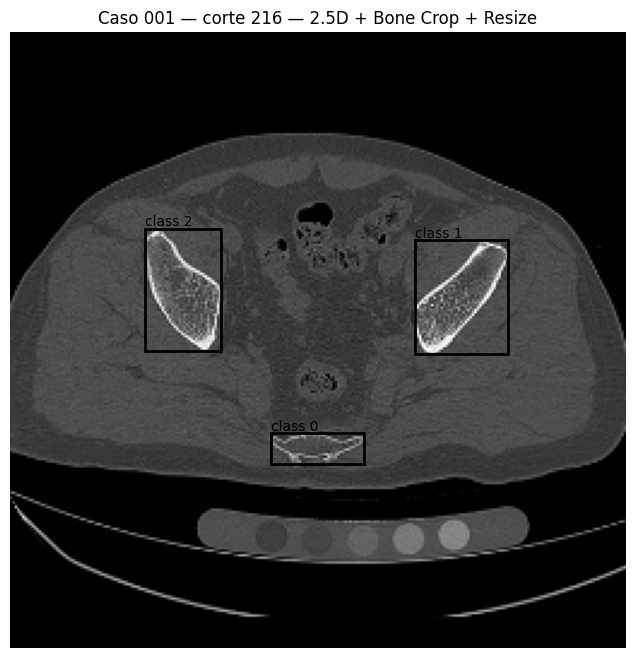

In [58]:
fig, ax = plt.subplots(figsize=(8, 8))

ax.imshow(
    image_25d_resized[1],
    cmap="gray",
    vmin=0,
    vmax=1,
)

for box, cls in zip(boxes_256, classes):

    x1, y1, x2, y2 = box

    rect = plt.Rectangle(
        (x1, y1),
        x2 - x1,
        y2 - y1,
        fill=False,
        linewidth=2,
    )

    ax.add_patch(rect)

    ax.text(
        x1,
        y1,
        f"class {cls}",
        fontsize=10,
        verticalalignment="bottom",
    )

ax.set_title(
    f"Caso {case['case_id']} — corte {z} — 2.5D + Bone Crop + Resize"
)

ax.axis("off")

plt.show()

In [59]:
from pengwin.data.dataset import PENGWINDataset

In [60]:
import inspect

print(inspect.signature(PENGWINDataset))

(data_dir, output_size=256, context_mm=2.0, crop_margin_mm=15.0, window_center=400, window_width=1800)


In [61]:
dataset = PENGWINDataset(
    data_dir=DATA_DIR,
    output_size=256,
    context_mm=2.0,
    crop_margin_mm=15.0,
    window_center=400,
    window_width=1800,
)

In [62]:
image_tensor, target = dataset[0]

print("===== IMAGE =====")
print("Shape:", image_tensor.shape)
print("Dtype:", image_tensor.dtype)
print("Min:", image_tensor.min().item())
print("Max:", image_tensor.max().item())

print("\n===== TARGET =====")
print("Boxes:")
print(target["boxes"])

print("\nLabels:")
print(target["labels"])

===== IMAGE =====
Shape: torch.Size([3, 256, 256])
Dtype: torch.float32
Min: 0.0
Max: 1.0

===== TARGET =====
Boxes:
tensor([[107.9267, 166.3218, 147.0306, 179.3564],
        [167.8860,  86.0285, 206.9898, 133.9959],
        [ 55.7882,  81.3361,  87.5927, 132.4318]])

Labels:
tensor([0, 1, 2])


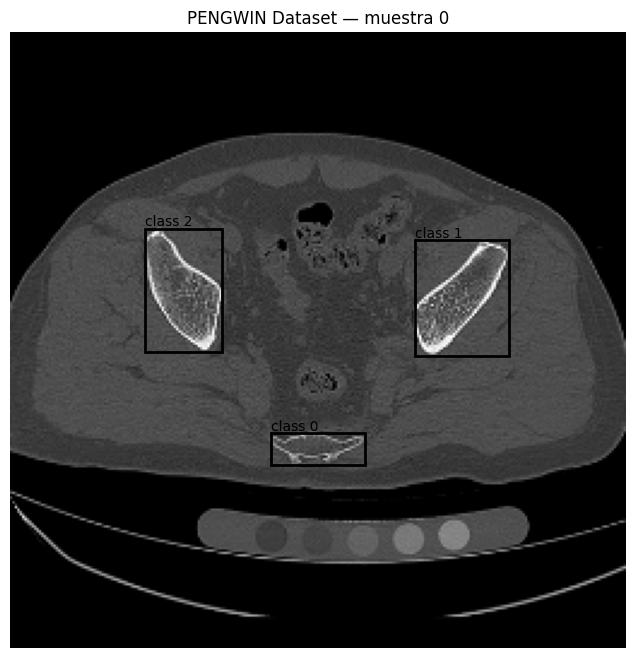

In [63]:
fig, ax = plt.subplots(figsize=(8, 8))

# Canal central del 2.5D
ax.imshow(
    image_tensor[1].numpy(),
    cmap="gray",
    vmin=0,
    vmax=1,
)

# Dibujar bounding boxes
for box, cls in zip(
    target["boxes"].numpy(),
    target["labels"].numpy(),
):

    x1, y1, x2, y2 = box

    rect = plt.Rectangle(
        (x1, y1),
        x2 - x1,
        y2 - y1,
        fill=False,
        linewidth=2,
    )

    ax.add_patch(rect)

    ax.text(
        x1,
        y1,
        f"class {cls}",
        fontsize=10,
        verticalalignment="bottom",
    )

ax.set_title("PENGWIN Dataset — muestra 0")
ax.axis("off")

plt.show()

In [64]:
def detection_collate_fn(batch):
    """
    Agrupa muestras de detección sin exigir
    que todas tengan el mismo número de boxes.
    """

    images = []
    targets = []

    for image, target in batch:
        images.append(image)
        targets.append(target)

    images = torch.stack(images, dim=0)

    return images, targets

In [65]:
loader = DataLoader(
    dataset,
    batch_size=4,
    shuffle=False,
    num_workers=0,
    collate_fn=detection_collate_fn,
)

print("DataLoader creado correctamente.")

DataLoader creado correctamente.


In [66]:
images, targets = next(iter(loader))

print("===== BATCH =====")
print("Images shape:", images.shape)

print("\nNúmero de targets:", len(targets))

for i, target in enumerate(targets):

    print(f"\nMuestra {i}:")
    print("  Boxes:", target["boxes"].shape)
    print("  Labels:", target["labels"].shape)

===== BATCH =====
Images shape: torch.Size([4, 3, 256, 256])

Número de targets: 4

Muestra 0:
  Boxes: torch.Size([3, 4])
  Labels: torch.Size([3])

Muestra 1:
  Boxes: torch.Size([3, 4])
  Labels: torch.Size([3])

Muestra 2:
  Boxes: torch.Size([3, 4])
  Labels: torch.Size([3])

Muestra 3:
  Boxes: torch.Size([3, 4])
  Labels: torch.Size([3])


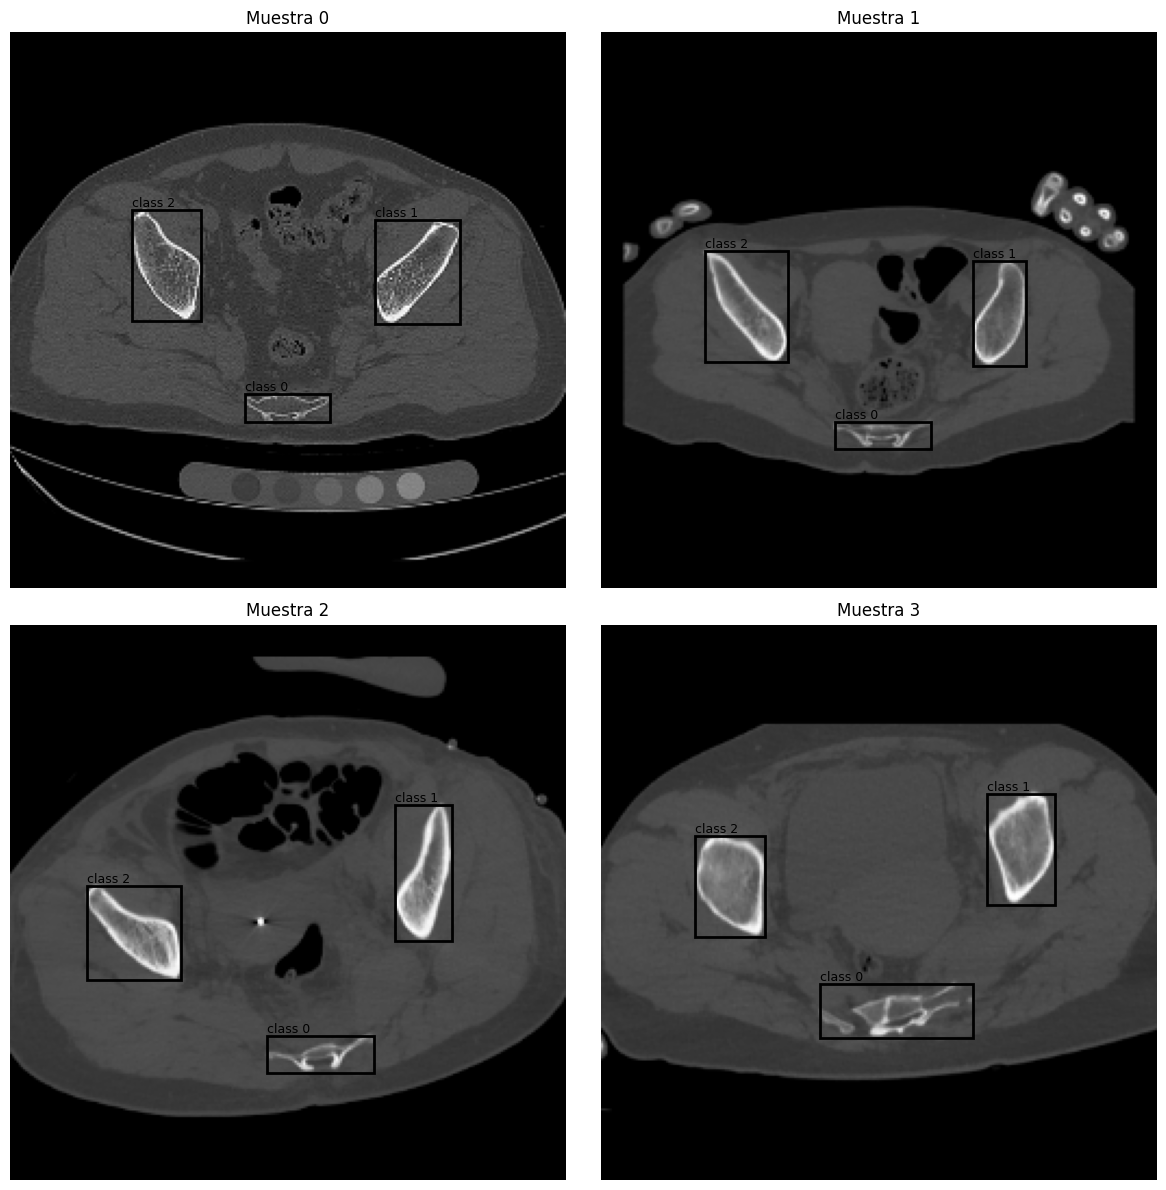

In [67]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 12),
)

axes = axes.flatten()

for i, ax in enumerate(axes):

    ax.imshow(
        images[i][1].numpy(),
        cmap="gray",
        vmin=0,
        vmax=1,
    )

    boxes = targets[i]["boxes"].numpy()
    labels = targets[i]["labels"].numpy()

    for box, cls in zip(boxes, labels):

        x1, y1, x2, y2 = box

        rect = plt.Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            fill=False,
            linewidth=2,
        )

        ax.add_patch(rect)

        ax.text(
            x1,
            y1,
            f"class {cls}",
            fontsize=9,
            verticalalignment="bottom",
        )

    ax.set_title(f"Muestra {i}")
    ax.axis("off")

plt.tight_layout()
plt.show()